In [6]:
!pip install pandas
!pip install pandas numpy scikit-learn matplotlib seaborn
!pip install matplotlib.pyplot

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot


In [7]:
#importing data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#loading dataset
data  = pd.read_csv("titanic.csv.csv")
data.columns = data.columns.str.strip()

pd.set_option('display.max_columns', None)

print(data.head())
print(data.info())
print(data.describe())

data.isnull().sum()

   Survived  Pclass                                               Name  \
0       0.0     3.0                             Mr. Owen Harris Braund   
1       1.0     1.0  Mrs. John Bradley (Florence Briggs Thayer) Cum...   
2       1.0     3.0                              Miss. Laina Heikkinen   
3       1.0     1.0        Mrs. Jacques Heath (Lily May Peel) Futrelle   
4       0.0     3.0                            Mr. William Henry Allen   

      Sex   Age  Sibsp  Parch     Fare Embarked  
0    male  22.0    1.0    0.0   7.2500        S  
1  female  38.0    1.0    0.0  71.2833        C  
2  female  26.0    0.0    0.0   7.9250        S  
3  female  35.0    1.0    0.0  53.1000        S  
4    male  35.0    0.0    0.0   8.0500        S  
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  887 non-null    float64
 1   Pclass    887 non-null    float64
 2   N

Survived    4
Pclass      4
Name        4
Sex         4
Age         4
Sibsp       4
Parch       4
Fare        4
Embarked    2
dtype: int64

In [13]:
#total number of male passangers on the ship 
adult_males_count = data[
    (data['Sex'] == 'male') &
    (data['Age'] >= 18)
].shape[0]

print(f"Total Adult Male Passengers: {adult_males_count}")

Total Adult Male Passengers: 506


In [15]:
#percentage of ship that were adult males 
adult_males_count = len(
    data[
        (data['Sex'] == 'male') &
        (data['Age'] >= 18)
    ]
)

total_passengers = len(data)

percentage = (adult_males_count / total_passengers) * 100

print(f"Adult males = {percentage:.2f}% of all passengers")

Adult males = 56.79% of all passengers


In [ ]:
#males accross each class
# Filter adult males
adult_males = data[
    (data['Sex'] == 'male') &
    (data['Age'] >= 18)
]

# Count adult males in each class
class_distribution = adult_males['Pclass'].value_counts().sort_index()

print(class_distribution)

Pclass
1.0    118
2.0     97
3.0    291
Name: count, dtype: int64


In [19]:
#percentage of males in each class
percentage_distribution = (
    adult_males['Pclass']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print(percentage_distribution.round(2))

Pclass
1.0    23.32
2.0    19.17
3.0    57.51
Name: proportion, dtype: float64


In [26]:
# Filter adult male survivors
adult_male_survivors = data[
    (data['Sex'] == 'male') &
    (data['Age'] >= 18) &
    (data['Survived'] == 1)
]

# Count survivors in each class
survivors_by_class = adult_male_survivors.groupby('Pclass').size()

print(survivors_by_class)

Pclass
1.0    41
2.0     8
3.0    35
dtype: int64


In [27]:
# Filter adult males
adult_males = data[
    (data['Sex'] == 'male') &
    (data['Age'] >= 18)
]

# Statistics by class
adult_male_stats = adult_males.groupby('Pclass').agg(
    Total_Adult_Males=('Survived', 'count'),
    Adult_Male_Survivors=('Survived', 'sum')
)

# Survival percentage
adult_male_stats['Survival_Percentage'] = (
    adult_male_stats['Adult_Male_Survivors']
    / adult_male_stats['Total_Adult_Males']
) * 100

print(adult_male_stats.round(2))

        Total_Adult_Males  Adult_Male_Survivors  Survival_Percentage
Pclass                                                              
1.0                   118                  41.0                34.75
2.0                    97                   8.0                 8.25
3.0                   291                  35.0                12.03


In [28]:

# Filter adult males
adult_males = data[
    (data['Sex'] == 'male') &
    (data['Age'] >= 18)
].copy()

# Create age groups
bins = [18, 40, 60, 80, 100]
labels = ['18-40', '40-60', '60-80', '80-100']

adult_males['Age_Group'] = pd.cut(
    adult_males['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Count adult males in each age group and class
adult_male_distribution = pd.crosstab(
    adult_males['Age_Group'],
    adult_males['Pclass']
)

print(adult_male_distribution)

Pclass     1.0  2.0  3.0
Age_Group               
18-40       56   75  253
40-60       49   19   32
60-80       13    3    6


In [32]:
#classification of age groups of number of adult male survivors in each class
# Adult male survivors
adult_male_survivors = data[
    (data['Sex'] == 'male') &
    (data['Age'] >= 18) &
    (data['Survived'] == 1)
].copy()

bins = [18, 40, 60, 80, 100]
labels = ['18-40', '40-60', '60-80', '80-100']

adult_male_survivors['Age_Group'] = pd.cut(
    adult_male_survivors['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)
survivor_distribution = pd.crosstab(
    adult_male_survivors['Age_Group'],
    adult_male_survivors['Pclass']
)

print(survivor_distribution)


Pclass     1.0  2.0  3.0
Age_Group               
18-40       24    6   33
40-60       16    1    2
60-80        1    1    0


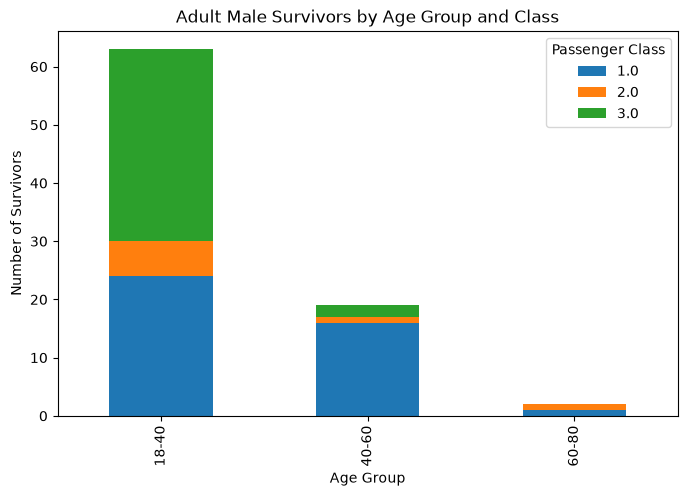

In [33]:
survivor_distribution.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Adult Male Survivors by Age Group and Class')
plt.xlabel('Age Group')
plt.ylabel('Number of Survivors')
plt.legend(title='Passenger Class')

plt.show()

In [34]:
# All adult males
adult_males = data[
    (data['Sex'] == 'male') &
    (data['Age'] >= 18)
].copy()

adult_males['Age_Group'] = pd.cut(
    adult_males['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

survival_rate = pd.crosstab(
    adult_males['Age_Group'],
    adult_males['Pclass'],
    values=adult_males['Survived'],
    aggfunc='mean'
) * 100

print(survival_rate.round(2))

Pclass       1.0    2.0    3.0
Age_Group                     
18-40      42.86   8.00  13.04
40-60      32.65   5.26   6.25
60-80       7.69  33.33   0.00


In [35]:
# Total passengers on ship
total_population = len(data)

# Filter adult males
adult_males = data[
    (data['Sex'] == 'male') &
    (data['Age'] >= 18)
].copy()

# Create age groups
bins = [18, 40, 60, 80, 100]
labels = ['18-40', '40-60', '60-80', '80-100']

adult_males['Age_Group'] = pd.cut(
    adult_males['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Keep only survivors
adult_male_survivors = adult_males[
    adult_males['Survived'] == 1
]

# Count survivors by Age Group and Class
survivor_counts = pd.crosstab(
    adult_male_survivors['Age_Group'],
    adult_male_survivors['Pclass']
)

# Convert to percentage of total ship population
survivor_percentages = (
    survivor_counts / total_population
) * 100

print(survivor_percentages.round(2))

Pclass      1.0   2.0   3.0
Age_Group                  
18-40      2.69  0.67  3.70
40-60      1.80  0.11  0.22
60-80      0.11  0.11  0.00


In [44]:
# Find the maximum fare
max_fare = data['Fare'].max()

print("Maximum Fare:", max_fare)

# Find passengers who paid the maximum fare
max_fare_passengers = data[data['Fare'] == max_fare]

# Count them
print("Number of passengers who paid the maximum fare:",
      len(max_fare_passengers))

print((data['Fare'] == data['Fare'].max()).sum())

# Find the maximum fare
max_fare = data['Fare'].max()

print("Maximum Fare:", max_fare)

# Find passengers who paid the maximum fare
max_fare_passengers = data[data['Fare'] == max_fare]

# Count them
print("Number of passengers who paid the maximum fare:",
      len(max_fare_passengers))

print((data['Fare'] == data['Fare'].max()).sum())

for index, passenger in max_fare_passengers.iterrows():
    print("\nPassenger", index)
    print("Name:", passenger['Name'])
    print("Sex:", passenger['Sex'])
    print("Age:", passenger['Age'])
    print("Class:", passenger['Pclass'])
    print("Fare:", passenger['Fare'])
    print("Survived:", "Yes" if passenger['Survived'] == 1 else "No")

Maximum Fare: 512.3292
Number of passengers who paid the maximum fare: 3
3
Maximum Fare: 512.3292
Number of passengers who paid the maximum fare: 3
3

Passenger 257
Name: Miss. Anna Ward
Sex: female
Age: 35.0
Class: 1.0
Fare: 512.3292
Survived: Yes

Passenger 676
Name: Mr. Thomas Drake Martinez Cardeza
Sex: male
Age: 36.0
Class: 1.0
Fare: 512.3292
Survived: Yes

Passenger 733
Name: Mr. Gustave J Lesurer
Sex: male
Age: 35.0
Class: 1.0
Fare: 512.3292
Survived: Yes


In [46]:
# Find oldest and youngest passengers
oldest = data.loc[data['Age'].idxmax()]
youngest = data.loc[data['Age'].idxmin()]

print("===== OLDEST PASSENGER =====")
print("Name:", oldest['Name'])
print("Age:", oldest['Age'])
print("Sex:", oldest['Sex'])
print("Class:", oldest['Pclass'])
print("Fare:", oldest['Fare'])
print("Survived:", "Yes" if oldest['Survived'] == 1 else "No")

print("\n===== YOUNGEST PASSENGER =====")
print("Name:", youngest['Name'])
print("Age:", youngest['Age'])
print("Sex:", youngest['Sex'])
print("Class:", youngest['Pclass'])
print("Fare:", youngest['Fare'])
print("Survived:", "Yes" if youngest['Survived'] == 1 else "No")
#oldest and youngest

comparison = pd.DataFrame([
    oldest[['Name', 'Age', 'Sex', 'Pclass', 'Fare', 'Survived']],
    youngest[['Name', 'Age', 'Sex', 'Pclass', 'Fare', 'Survived']]
], index=['Oldest', 'Youngest'])

print(comparison)


===== OLDEST PASSENGER =====
Name: Mr. Algernon Henry Wilson Barkworth
Age: 80.0
Sex: male
Class: 1.0
Fare: 30.0
Survived: Yes

===== YOUNGEST PASSENGER =====
Name: Master. Assad Alexander Thomas
Age: 0.42
Sex: male
Class: 3.0
Fare: 8.5167
Survived: Yes
                                         Name    Age   Sex  Pclass     Fare  \
Oldest    Mr. Algernon Henry Wilson Barkworth  80.00  male     1.0  30.0000   
Youngest       Master. Assad Alexander Thomas   0.42  male     3.0   8.5167   

          Survived  
Oldest         1.0  
Youngest       1.0  


In [47]:
# Male passengers only
males = data[data['Sex'] == 'male'].copy()

# Age groups
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '20-40', '40-60', '60-80', '80-100']

males['Age_Group'] = pd.cut(
    males['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

survival_rates = pd.pivot_table(
    males,
    values='Survived',
    index=['Pclass', 'Age_Group'],
    columns='Embarked',
    aggfunc='mean'
) * 100

print(survival_rates.round(2))


Embarked               C      Q      S
Pclass Age_Group                      
1.0    0-20       100.00  50.00  33.33
       20-40       44.44  62.50  41.67
       40-60       33.33  40.00  32.14
       60-80        0.00   0.00  10.00
2.0    0-20       100.00   0.00  52.94
       20-40       12.50   0.00   7.55
       40-60        0.00    NaN   5.88
       60-80         NaN    NaN  33.33
3.0    0-20        22.22   0.00  20.00
       20-40       15.38   7.14  12.84
       40-60        0.00  33.33   4.00
       60-80        0.00   0.00   0.00


In [48]:
stats = males.groupby(
    ['Embarked', 'Pclass', 'Age_Group']
).agg(
    Total_Males=('Survived', 'count'),
    Survivors=('Survived', 'sum')
)

stats['Survival_Rate'] = (
    stats['Survivors'] /
    stats['Total_Males']
) * 100

print(stats.round(2))

                           Total_Males  Survivors  Survival_Rate
Embarked Pclass Age_Group                                       
C        1.0    0-20                 2        2.0         100.00
                20-40                9        4.0          44.44
                40-60               15        5.0          33.33
                60-80                2        0.0           0.00
         2.0    0-20                 1        1.0         100.00
                20-40                8        1.0          12.50
                40-60                2        0.0           0.00
         3.0    0-20                18        4.0          22.22
                20-40               39        6.0          15.38
                40-60                4        0.0           0.00
                60-80                1        0.0           0.00
Q        1.0    0-20                 2        1.0          50.00
                20-40                8        5.0          62.50
                40-60    